# Veri Seti ve Deney Karsilastirma Notebook'u

Bu notebook, `HUMAN / NON_HUMAN` problemi icin secilen veri setlerini Turkce olarak ozetler ve
asagidaki kombinasyonlari ayni model ailesi ile karsilastirir:

- `NIGENS`
- `ESC-50 + TESS`
- `NIGENS + ESC-50`
- `NIGENS + TESS`
- `NIGENS + ESC-50 + TESS`

Amac, rapor icin tek bir noktadan okunabilir tablo ve grafikler uretmektir.

## 1. Kutuphaneler

In [1]:
import gc
import random
import warnings
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display
from scipy.signal import butter, fftconvolve, sosfiltfilt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_SPLIT = True
except ImportError:
    StratifiedGroupKFold = None
    HAS_STRATIFIED_GROUP_SPLIT = False

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## 2. Ayarlar

In [2]:
PROJECT_ROOT = Path(r"C:\projs\echo_swarm2")

NIGENS_ROOT = PROJECT_ROOT / "dataset" / "nigens" / "NIGENS" / "NIGENS"
ESC50_ROOT = PROJECT_ROOT / "dataset" / "esc-50" / "ESC-50-master"
ESC50_AUDIO_DIR = ESC50_ROOT / "audio"
ESC50_META_PATH = ESC50_ROOT / "meta" / "esc50.csv"
TESS_ROOT = PROJECT_ROOT / "dataset" / "tess" / "doi-10.5683-sp2-e8h2mf"

QUICK_TEST_ROOT = PROJECT_ROOT / "demo_samples" / "nigens_quick_test"
QUICK_TEST_MANIFEST = QUICK_TEST_ROOT / "manifest.csv"
RUBBLE_TEST_ROOT = PROJECT_ROOT / "demo_samples" / "nigens_rubble_test"
RUBBLE_TEST_MANIFEST = RUBBLE_TEST_ROOT / "manifest.csv"

MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = OUTPUTS_DIR / "dataset_combo_comparison_results_tr.csv"
RESULTS_PNG = OUTPUTS_DIR / "dataset_combo_comparison_bar_tr.png"
HEATMAP_PNG = OUTPUTS_DIR / "dataset_combo_comparison_heatmap_tr.png"

SEED = 42
TEST_SIZE = 0.20
SAMPLE_RATE = 16_000
CLIP_SECONDS = 1.5
CLIP_SAMPLES = int(SAMPLE_RATE * CLIP_SECONDS)
BATCH_SIZE = 32
NUM_EPOCHS = 12
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 3
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256
LOWPASS_PROB = 0.45
NOISE_PROB = 0.45
REVERB_PROB = 0.20
TESS_MAX_WORDS_PER_SPEAKER = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LABEL_TO_IDX = {"NON_HUMAN": 0, "HUMAN": 1}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

EXPERIMENTS = [
    {"name": "NIGENS", "datasets": ["NIGENS"]},
    {"name": "ESC50_TESS", "datasets": ["ESC50", "TESS"]},
    {"name": "NIGENS_ESC50", "datasets": ["NIGENS", "ESC50"]},
    {"name": "NIGENS_TESS", "datasets": ["NIGENS", "TESS"]},
    {"name": "NIGENS_ESC50_TESS", "datasets": ["NIGENS", "ESC50", "TESS"]},
]

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"Device: {DEVICE}")
print(f"Results CSV: {RESULTS_CSV}")


Device: cuda
Results CSV: C:\projs\echo_swarm2\outputs\dataset_combo_comparison_results_tr.csv


## 3. Veri Seti Ozetleri

In [3]:
dataset_summary_df = pd.DataFrame(
    [
        {
            "Veri Seti": "NIGENS",
            "Turkce Aciklama": "Insan sesi ve cevresel olay seslerini birlikte veren olay veri seti",
            "Toplam Ses": 898,
            "Projede Nasil Kullaniliyor": "Ana benchmark ve temel insan/insan olmayan ayrimi",
            "Secilen Pozitif Ornekler": "femaleSpeech, maleSpeech, femaleScream, maleScream",
            "Secilen Negatif Ornekler": "alarm, crash, dog, engine, fire, knock, phone",
            "Not": "baby, general, footsteps, piano disarida tutuldu",
        },
        {
            "Veri Seti": "ESC-50",
            "Turkce Aciklama": "Cok cesitli cevresel ses veri seti",
            "Toplam Ses": 2000,
            "Projede Nasil Kullaniliyor": "Zorlayici NON_HUMAN sinifini guclendirme ve secili insan sesleri ekleme",
            "Secilen Pozitif Ornekler": "breathing, coughing, laughing, sneezing, snoring",
            "Secilen Negatif Ornekler": "animal, machine, alarm, impact turunden secili siniflar",
            "Not": "footsteps ve crying_baby disarida tutuldu",
        },
        {
            "Veri Seti": "TESS",
            "Turkce Aciklama": "Duygusal tonlar iceren insan konusma veri seti",
            "Toplam Ses": 2800,
            "Projede Nasil Kullaniliyor": "HUMAN sinifinda konusma cesitliligini artirma",
            "Secilen Pozitif Ornekler": "Tum konusma kayitlari, kontrollu ornekleme ile",
            "Secilen Negatif Ornekler": "-",
            "Not": "2 konusmaci, 7 duygu; temiz kayit agirlikli",
        },
        {
            "Veri Seti": "human_screaming_detection",
            "Turkce Aciklama": "Ciglik / ciglik degil ayrimi icin temel eski veri seti",
            "Toplam Ses": 3128,
            "Projede Nasil Kullaniliyor": "Eski baseline referansi",
            "Secilen Pozitif Ornekler": "scream",
            "Secilen Negatif Ornekler": "non_scream",
            "Not": "Insan sesi kavrami dar; daha cok scream tespiti icin uygun",
        },
        {
            "Veri Seti": "human_screaming_detection2",
            "Turkce Aciklama": "Ikinci ciglik veri seti",
            "Toplam Ses": 3493,
            "Projede Nasil Kullaniliyor": "Dis test veya ek scream kaynagi olarak kullanilabilir",
            "Secilen Pozitif Ornekler": "Screaming",
            "Secilen Negatif Ornekler": "NotScreaming",
            "Not": "Negatif sinif daha baskin",
        },
        {
            "Veri Seti": "cough_speech_sneeze",
            "Turkce Aciklama": "Solunum ve benzeri insan kaynakli sesleri iceren veri yapisi",
            "Toplam Ses": 920,
            "Projede Nasil Kullaniliyor": "Gerekirse HUMAN sinifini genisletmek icin yardimci set",
            "Secilen Pozitif Ornekler": "respiratory / breathing benzeri kayitlar",
            "Secilen Negatif Ornekler": "-",
            "Not": "Etiketleme goreve ozel yorum gerektirir",
        },
        {
            "Veri Seti": "cough_audio_dataset",
            "Turkce Aciklama": "Oksuruk / oksuruk degil veri seti",
            "Toplam Ses": 13244,
            "Projede Nasil Kullaniliyor": "Ileride secici ek kaynak olabilir",
            "Secilen Pozitif Ornekler": "coughs",
            "Secilen Negatif Ornekler": "not_coughs",
            "Not": "Sinif dagilimi asiri dengesiz",
        },
        {
            "Veri Seti": "turkish-speech-dataset",
            "Turkce Aciklama": "Turkce konusma veri seti",
            "Toplam Ses": 304,
            "Projede Nasil Kullaniliyor": "Ileride Turkce konusma destegi icin yardimci set olabilir",
            "Secilen Pozitif Ornekler": "mutlu2, normal2",
            "Secilen Negatif Ornekler": "-",
            "Not": "Boyutu kucuk",
        },
        {
            "Veri Seti": "baby_screaming_detection",
            "Turkce Aciklama": "Bebek aglamasi ve iliskili durumlari iceren veri seti",
            "Toplam Ses": 1197,
            "Projede Nasil Kullaniliyor": "Bu asamada kullanilmiyor",
            "Secilen Pozitif Ornekler": "-",
            "Secilen Negatif Ornekler": "-",
            "Not": "Bebek sesi sonraki fazda ayrica ele alinacak",
        },
    ]
)

display(dataset_summary_df)


,Veri Seti,Turkce Aciklama,Toplam Ses,Projede Nasil Kullaniliyor,Secilen Pozitif Ornekler,Secilen Negatif Ornekler,Not
0,NIGENS,Insan sesi ve cevresel olay seslerini birlikte...,898,Ana benchmark ve temel insan/insan olmayan ayrimi,"femaleSpeech, maleSpeech, femaleScream, maleSc...","alarm, crash, dog, engine, fire, knock, phone","baby, general, footsteps, piano disarida tutuldu"
1,ESC-50,Cok cesitli cevresel ses veri seti,2000,Zorlayici NON_HUMAN sinifini guclendirme ve se...,"breathing, coughing, laughing, sneezing, snoring","animal, machine, alarm, impact turunden secili...",footsteps ve crying_baby disarida tutuldu
2,TESS,Duygusal tonlar iceren insan konusma veri seti,2800,HUMAN sinifinda konusma cesitliligini artirma,"Tum konusma kayitlari, kontrollu ornekleme ile",-,"2 konusmaci, 7 duygu; temiz kayit agirlikli"
3,human_screaming_detection,Ciglik / ciglik degil ayrimi icin temel eski v...,3128,Eski baseline referansi,scream,non_scream,Insan sesi kavrami dar; daha cok scream tespit...
4,human_screaming_detection2,Ikinci ciglik veri seti,3493,Dis test veya ek scream kaynagi olarak kullani...,Screaming,NotScreaming,Negatif sinif daha baskin
5,cough_speech_sneeze,Solunum ve benzeri insan kaynakli sesleri icer...,920,Gerekirse HUMAN sinifini genisletmek icin yard...,respiratory / breathing benzeri kayitlar,-,Etiketleme goreve ozel yorum gerektirir
6,cough_audio_dataset,Oksuruk / oksuruk degil veri seti,13244,Ileride secici ek kaynak olabilir,coughs,not_coughs,Sinif dagilimi asiri dengesiz
7,turkish-speech-dataset,Turkce konusma veri seti,304,Ileride Turkce konusma destegi icin yardimci s...,"mutlu2, normal2",-,Boyutu kucuk
8,baby_screaming_detection,Bebek aglamasi ve iliskili durumlari iceren ve...,1197,Bu asamada kullanilmiyor,-,-,Bebek sesi sonraki fazda ayrica ele alinacak


## 4. Etiketleme ve Veri Toplama Fonksiyonlari

In [4]:
NIGENS_HUMAN_CLASSES = [
    "femaleScream",
    "maleScream",
    "femaleSpeech",
    "maleSpeech",
]

NIGENS_NON_HUMAN_CLASSES = [
    "alarm",
    "crash",
    "dog",
    "engine",
    "fire",
    "knock",
    "phone",
]

ESC50_HUMAN_CLASSES = [
    "breathing",
    "coughing",
    "laughing",
    "sneezing",
    "snoring",
]

ESC50_NON_HUMAN_CLASSES = [
    "airplane",
    "car_horn",
    "cat",
    "chainsaw",
    "church_bells",
    "clock_alarm",
    "cow",
    "crackling_fire",
    "crow",
    "dog",
    "door_wood_knock",
    "engine",
    "frog",
    "glass_breaking",
    "hand_saw",
    "helicopter",
    "hen",
    "pig",
    "rooster",
    "sheep",
    "siren",
    "train",
    "vacuum_cleaner",
    "washing_machine",
]


def collect_nigens_records(root: Path) -> pd.DataFrame:
    rows = []
    for source_class in NIGENS_HUMAN_CLASSES:
        for wav_path in sorted((root / source_class).glob("*.wav")):
            rows.append(
                {
                    "path": str(wav_path),
                    "source_dataset": "NIGENS",
                    "source_class": source_class,
                    "target_label": "HUMAN",
                    "label_idx": LABEL_TO_IDX["HUMAN"],
                    "group_id": f"NIGENS_{wav_path.stem}",
                }
            )
    for source_class in NIGENS_NON_HUMAN_CLASSES:
        for wav_path in sorted((root / source_class).glob("*.wav")):
            rows.append(
                {
                    "path": str(wav_path),
                    "source_dataset": "NIGENS",
                    "source_class": source_class,
                    "target_label": "NON_HUMAN",
                    "label_idx": LABEL_TO_IDX["NON_HUMAN"],
                    "group_id": f"NIGENS_{wav_path.stem}",
                }
            )
    return pd.DataFrame(rows)


def collect_esc50_records(meta_path: Path, audio_dir: Path) -> pd.DataFrame:
    meta_df = pd.read_csv(meta_path)
    allowed_categories = set(ESC50_HUMAN_CLASSES + ESC50_NON_HUMAN_CLASSES)
    meta_df = meta_df[meta_df["category"].isin(allowed_categories)].copy()
    meta_df["target_label"] = np.where(meta_df["category"].isin(ESC50_HUMAN_CLASSES), "HUMAN", "NON_HUMAN")
    meta_df["label_idx"] = meta_df["target_label"].map(LABEL_TO_IDX)
    meta_df["path"] = meta_df["filename"].apply(lambda name: str(audio_dir / name))
    meta_df["source_dataset"] = "ESC50"
    meta_df["source_class"] = meta_df["category"]
    meta_df["group_id"] = meta_df["src_file"].astype(str).apply(lambda value: f"ESC50_{value}")
    return meta_df[["path", "source_dataset", "source_class", "target_label", "label_idx", "group_id"]].reset_index(drop=True)


def collect_tess_records(root: Path, max_words_per_speaker: int = TESS_MAX_WORDS_PER_SPEAKER, seed: int = SEED) -> pd.DataFrame:
    wav_paths = sorted(root.glob("*.wav"))
    rows = []
    for wav_path in wav_paths:
        parts = wav_path.stem.split("_")
        if len(parts) < 3:
            continue
        speaker, word, emotion = parts[0], parts[1], parts[2]
        rows.append(
            {
                "path": str(wav_path),
                "source_dataset": "TESS",
                "source_class": "tess_speech",
                "target_label": "HUMAN",
                "label_idx": LABEL_TO_IDX["HUMAN"],
                "speaker": speaker,
                "word": word,
                "emotion": emotion,
                "group_id": f"TESS_{speaker}_{word}",
            }
        )

    tess_df = pd.DataFrame(rows)
    sampler = random.Random(seed)
    selected_groups = []
    for speaker, speaker_df in tess_df.groupby("speaker"):
        groups = sorted(speaker_df["group_id"].unique().tolist())
        selected_groups.extend(sampler.sample(groups, k=min(max_words_per_speaker, len(groups))))

    tess_df = tess_df[tess_df["group_id"].isin(selected_groups)].reset_index(drop=True)
    return tess_df[["path", "source_dataset", "source_class", "target_label", "label_idx", "group_id"]]


nigens_df = collect_nigens_records(NIGENS_ROOT)
esc50_df = collect_esc50_records(ESC50_META_PATH, ESC50_AUDIO_DIR)
tess_df = collect_tess_records(TESS_ROOT)

all_sources = {"NIGENS": nigens_df, "ESC50": esc50_df, "TESS": tess_df}

dataset_summary_df = (
    pd.concat([nigens_df, esc50_df, tess_df], ignore_index=True)
    .groupby(["source_dataset", "target_label"], dropna=False)
    .size()
    .reset_index(name="Ornek Sayisi")
    .rename(columns={"source_dataset": "Kaynak Veri Seti"})
)

display(dataset_summary_df)


,Kaynak Veri Seti,target_label,Ornek Sayisi
0,ESC50,HUMAN,200
1,ESC50,NON_HUMAN,960
2,NIGENS,HUMAN,156
3,NIGENS,NON_HUMAN,315
4,TESS,HUMAN,896


## 5. Ses On Isleme

In [5]:
def load_audio(path: str, target_sr: int = SAMPLE_RATE) -> np.ndarray:
    waveform, sr = librosa.load(path, sr=None, mono=True)
    waveform = waveform.astype(np.float32)
    if sr != target_sr:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=target_sr)
    return waveform.astype(np.float32)


def crop_or_pad(waveform: np.ndarray, target_length: int = CLIP_SAMPLES, training: bool = False) -> np.ndarray:
    current_length = len(waveform)
    if current_length > target_length:
        start = random.randint(0, current_length - target_length) if training else (current_length - target_length) // 2
        waveform = waveform[start : start + target_length]
    elif current_length < target_length:
        pad_total = target_length - current_length
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        waveform = np.pad(waveform, (pad_left, pad_right), mode="constant")
    return waveform.astype(np.float32)


def lowpass_filter(waveform: np.ndarray, sr: int = SAMPLE_RATE, cutoff_hz: float | None = None) -> np.ndarray:
    cutoff_hz = cutoff_hz or random.uniform(700.0, 4500.0)
    nyquist = sr / 2.0
    sos = butter(6, min(cutoff_hz / nyquist, 0.95), btype="low", output="sos")
    return sosfiltfilt(sos, waveform).astype(np.float32)


def build_impulse_response(sr: int = SAMPLE_RATE) -> np.ndarray:
    length = max(int(sr * 0.14), 8)
    t = np.linspace(0.0, 1.0, length, endpoint=False, dtype=np.float32)
    ir = np.exp(-8.0 * t)
    for pos, gain in zip([0, int(sr * 0.018), int(sr * 0.043), int(sr * 0.070)], [1.0, 0.32, 0.18, 0.08]):
        if pos < len(ir):
            ir[pos] += gain
    ir /= np.sum(np.abs(ir)) + 1e-8
    return ir.astype(np.float32)


def apply_reverb(waveform: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    ir = build_impulse_response(sr)
    return fftconvolve(waveform, ir, mode="full")[: len(waveform)].astype(np.float32)


def add_noise(waveform: np.ndarray) -> np.ndarray:
    snr_db = random.uniform(6.0, 18.0)
    clean_rms = np.sqrt(np.mean(waveform**2) + 1e-8)
    noise = np.random.normal(0.0, 1.0, size=waveform.shape).astype(np.float32)
    noise_rms = np.sqrt(np.mean(noise**2) + 1e-8)
    desired_noise_rms = clean_rms / (10 ** (snr_db / 20.0))
    noise = noise * (desired_noise_rms / noise_rms)
    return (waveform + noise).astype(np.float32)


def augment_waveform(waveform: np.ndarray) -> np.ndarray:
    augmented = waveform.copy()
    if random.random() < LOWPASS_PROB:
        augmented = lowpass_filter(augmented)
    if random.random() < REVERB_PROB:
        augmented = apply_reverb(augmented)
    if random.random() < NOISE_PROB:
        augmented = add_noise(augmented)
    peak = np.max(np.abs(augmented)) + 1e-8
    augmented = 0.95 * augmented / peak
    return np.clip(augmented, -1.0, 1.0).astype(np.float32)


def waveform_to_logmel(
    waveform: np.ndarray,
    sr: int = SAMPLE_RATE,
    n_mels: int = N_MELS,
    n_fft: int = N_FFT,
    hop_length: int = HOP_LENGTH,
) -> np.ndarray:
    mel = librosa.feature.melspectrogram(y=waveform, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return ((log_mel - log_mel.mean()) / (log_mel.std() + 1e-6)).astype(np.float32)


## 6. Dataset, Model ve Yardimci Fonksiyonlar

In [6]:
class AudioDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, training: bool = False):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.training = training

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]
        waveform = crop_or_pad(load_audio(row["path"]), training=self.training)
        if self.training:
            waveform = augment_waveform(waveform)
        feature = torch.tensor(waveform_to_logmel(waveform), dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(int(row["label_idx"]), dtype=torch.long)
        return feature, label


class SmallAudioCNN(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.15),
            nn.Linear(32, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


def make_group_split(df: pd.DataFrame):
    if HAS_STRATIFIED_GROUP_SPLIT:
        splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
        train_idx, val_idx = next(splitter.split(df, y=df["target_label"], groups=df["group_id"]))
    else:
        splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
        train_idx, val_idx = next(splitter.split(df, groups=df["group_id"]))
    return train_idx, val_idx


def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for features, labels in dataloader:
        features = features.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(is_train):
            logits = model(features)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    epoch_loss = total_loss / len(dataloader.dataset)
    epoch_acc = float(np.mean(np.array(all_preds) == np.array(all_labels)))
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


def predict_dataframe(model, dataframe: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    loader = DataLoader(AudioDataset(dataframe, training=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    model.eval()
    labels_list, preds_list = [], []
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(DEVICE, non_blocking=True)
            logits = model(features)
            preds = torch.argmax(logits, dim=1)
            labels_list.extend(labels.numpy().tolist())
            preds_list.extend(preds.cpu().numpy().tolist())
    return np.array(labels_list), np.array(preds_list)


## 7. Deney Veri Cercevelerini Olusturma

In [7]:
def build_experiment_dataframe(dataset_names: list[str]) -> pd.DataFrame:
    frames = [all_sources[name].copy() for name in dataset_names]
    df = pd.concat(frames, ignore_index=True)
    df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return df


preview_rows = []
for exp in EXPERIMENTS:
    exp_df = build_experiment_dataframe(exp["datasets"])
    preview_rows.append(
        {
            "Deney": exp["name"],
            "Kullanilan Veri Setleri": " + ".join(exp["datasets"]),
            "Toplam Ornek": len(exp_df),
            "HUMAN Sayisi": int((exp_df["target_label"] == "HUMAN").sum()),
            "NON_HUMAN Sayisi": int((exp_df["target_label"] == "NON_HUMAN").sum()),
        }
    )

experiment_preview_df = pd.DataFrame(preview_rows)
display(experiment_preview_df)


,Deney,Kullanilan Veri Setleri,Toplam Ornek,HUMAN Sayisi,NON_HUMAN Sayisi
0,NIGENS,NIGENS,471,156,315
1,ESC50_TESS,ESC50 + TESS,2056,1096,960
2,NIGENS_ESC50,NIGENS + ESC50,1631,356,1275
3,NIGENS_TESS,NIGENS + TESS,1367,1052,315
4,NIGENS_ESC50_TESS,NIGENS + ESC50 + TESS,2527,1252,1275


## 8. Demo Benchmark Fonksiyonlari

In [8]:
def load_checkpoint_for_inference(model_path: Path):
    checkpoint = torch.load(model_path, map_location=DEVICE)
    inference_model = SmallAudioCNN(num_classes=len(checkpoint["label_to_idx"])).to(DEVICE)
    inference_model.load_state_dict(checkpoint["model_state_dict"])
    inference_model.eval()
    return inference_model, checkpoint


def predict_single_wav(wav_path: str, model_path: Path) -> dict:
    inference_model, checkpoint = load_checkpoint_for_inference(model_path)
    waveform = load_audio(wav_path, target_sr=checkpoint["config"]["sample_rate"])
    waveform = crop_or_pad(waveform, target_length=int(checkpoint["config"]["sample_rate"] * checkpoint["config"]["clip_seconds"]), training=False)
    logmel = waveform_to_logmel(
        waveform,
        sr=checkpoint["config"]["sample_rate"],
        n_mels=checkpoint["config"]["n_mels"],
        n_fft=checkpoint["config"]["n_fft"],
        hop_length=checkpoint["config"]["hop_length"],
    )
    feature = torch.tensor(logmel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = inference_model(feature)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    predicted_idx = int(np.argmax(probs))
    return {
        "predicted_label": IDX_TO_LABEL[predicted_idx],
        "human_probability": float(probs[LABEL_TO_IDX["HUMAN"]]),
        "non_human_probability": float(probs[LABEL_TO_IDX["NON_HUMAN"]]),
    }


def run_demo_benchmark(manifest_path: Path, folder_root: Path, model_path: Path):
    if not manifest_path.exists():
        return pd.NA, pd.NA
    manifest_df = pd.read_csv(manifest_path)
    rows = []
    for _, row in manifest_df.iterrows():
        if "variant_path" in manifest_df.columns:
            wav_path = row["variant_path"]
        else:
            subfolder = "human" if row["target_label"] == "HUMAN" else "non_human"
            wav_path = str(folder_root / subfolder / row["demo_name"])
        pred = predict_single_wav(wav_path, model_path=model_path)
        rows.append({"target_label": row["target_label"], "predicted_label": pred["predicted_label"]})
    result_df = pd.DataFrame(rows)
    accuracy = float((result_df["target_label"] == result_df["predicted_label"]).mean())
    human_recall_score = float(result_df.loc[result_df["target_label"] == "HUMAN", "predicted_label"].eq("HUMAN").mean())
    return accuracy, human_recall_score


## 9. Tum Deneyleri Calistir

In [9]:
def run_experiment(exp_name: str, dataset_names: list[str]) -> dict:
    seed_everything(SEED)
    exp_df = build_experiment_dataframe(dataset_names)
    train_idx, val_idx = make_group_split(exp_df)
    train_df = exp_df.iloc[train_idx].reset_index(drop=True)
    val_df = exp_df.iloc[val_idx].reset_index(drop=True)

    train_loader = DataLoader(AudioDataset(train_df, training=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(AudioDataset(val_df, training=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

    model = SmallAudioCNN(num_classes=len(LABEL_TO_IDX)).to(DEVICE)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array(sorted(LABEL_TO_IDX.values())),
        y=train_df["label_idx"].to_numpy(),
    )
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    best_state_dict = None
    best_val_macro_f1 = -1.0
    best_val_human_recall = -1.0
    patience_counter = 0
    history_rows = []

    model_path = MODELS_DIR / f"comparison_{exp_name.lower()}.pt"

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_loss, val_acc, val_labels, val_preds = run_epoch(model, val_loader, criterion, optimizer=None)

        val_macro_f1 = f1_score(val_labels, val_preds, average="macro")
        val_human_recall = recall_score(val_labels, val_preds, pos_label=LABEL_TO_IDX["HUMAN"])

        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "val_macro_f1": val_macro_f1,
                "val_human_recall": val_human_recall,
            }
        )

        print(
            f"[{exp_name}] Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | "
            f"val_macro_f1={val_macro_f1:.4f} | val_human_recall={val_human_recall:.4f}"
        )

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_val_human_recall = val_human_recall
            best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            torch.save(
                {
                    "model_state_dict": best_state_dict,
                    "label_to_idx": LABEL_TO_IDX,
                    "config": {
                        "sample_rate": SAMPLE_RATE,
                        "clip_seconds": CLIP_SECONDS,
                        "n_mels": N_MELS,
                        "n_fft": N_FFT,
                        "hop_length": HOP_LENGTH,
                    },
                },
                model_path,
            )
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"[{exp_name}] Early stopping tetiklendi.")
            break

    model.load_state_dict(best_state_dict)
    val_labels, val_preds = predict_dataframe(model, val_df)
    report = classification_report(
        val_labels,
        val_preds,
        labels=[0, 1],
        target_names=[IDX_TO_LABEL[0], IDX_TO_LABEL[1]],
        output_dict=True,
        digits=4,
        zero_division=0,
    )

    quick_acc, quick_hrec = run_demo_benchmark(QUICK_TEST_MANIFEST, QUICK_TEST_ROOT, model_path)
    rubble_acc, rubble_hrec = run_demo_benchmark(RUBBLE_TEST_MANIFEST, RUBBLE_TEST_ROOT, model_path)

    row = {
        "Deney": exp_name,
        "Kullanilan Veri Setleri": " + ".join(dataset_names),
        "Toplam Ornek": len(exp_df),
        "Val Accuracy": float((val_labels == val_preds).mean()),
        "Val Macro F1": float(report["macro avg"]["f1-score"]),
        "HUMAN Recall": float(report["HUMAN"]["recall"]),
        "Quick Test Accuracy": quick_acc,
        "Quick Test HUMAN Recall": quick_hrec,
        "Rubble Test Accuracy": rubble_acc,
        "Rubble Test HUMAN Recall": rubble_hrec,
        "Model Yolu": str(model_path),
    }

    del model, train_loader, val_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return row


RUN_ALL_EXPERIMENTS = True

if RUN_ALL_EXPERIMENTS:
    results = []
    for exp in EXPERIMENTS:
        print(f"\n===== Basliyor: {exp['name']} =====")
        results.append(run_experiment(exp["name"], exp["datasets"]))
    results_df = pd.DataFrame(results)
    results_df.to_csv(RESULTS_CSV, index=False)
    print(f"Sonuclar kaydedildi: {RESULTS_CSV}")
else:
    print("Deneyler kapali. RUN_ALL_EXPERIMENTS = True yaparak calistirabilirsiniz.")



===== Basliyor: NIGENS =====


[NIGENS] Epoch 01/12 | train_acc=0.4562 | val_acc=0.3298 | val_macro_f1=0.2593 | val_human_recall=1.0000


[NIGENS] Epoch 02/12 | train_acc=0.6340 | val_acc=0.5106 | val_macro_f1=0.5086 | val_human_recall=0.7000


[NIGENS] Epoch 03/12 | train_acc=0.6552 | val_acc=0.7128 | val_macro_f1=0.7053 | val_human_recall=0.8667


[NIGENS] Epoch 04/12 | train_acc=0.7109 | val_acc=0.6596 | val_macro_f1=0.5524 | val_human_recall=0.2667


...

[NIGENS_ESC50_TESS] Epoch 08/12 | train_acc=0.8664 | val_acc=0.8735 | val_macro_f1=0.8711 | val_human_recall=0.7530


[NIGENS_ESC50_TESS] Epoch 09/12 | train_acc=0.8644 | val_acc=0.8444 | val_macro_f1=0.8444 | val_human_recall=0.8645


[NIGENS_ESC50_TESS] Epoch 10/12 | train_acc=0.8629 | val_acc=0.8716 | val_macro_f1=0.8703 | val_human_recall=0.7888


[NIGENS_ESC50_TESS] Epoch 11/12 | train_acc=0.8669 | val_acc=0.8696 | val_macro_f1=0.8673 | val_human_recall=0.7530
[NIGENS_ESC50_TESS] Early stopping tetiklendi.


Sonuclar kaydedildi: C:\projs\echo_swarm2\outputs\dataset_combo_comparison_results_tr.csv


## 10. Turkce Sonuc Tablosu

In [10]:
if RESULTS_CSV.exists():
    results_df = pd.read_csv(RESULTS_CSV)
    display(results_df.sort_values("Val Macro F1", ascending=False).reset_index(drop=True))
else:
    print("Henuz sonuc dosyasi olusmadi.")


,Deney,Kullanilan Veri Setleri,Toplam Ornek,Val Accuracy,Val Macro F1,HUMAN Recall,Quick Test Accuracy,Quick Test HUMAN Recall,Rubble Test Accuracy,Rubble Test HUMAN Recall,Model Yolu
0,NIGENS_TESS,NIGENS + TESS,1367,0.908759,0.883794,0.899522,0.375,0.00,0.750,0.50,C:\projs\echo_swarm2\models\comparison_nigens_...
1,ESC50_TESS,ESC50 + TESS,2056,0.883544,0.883328,0.809735,0.625,0.25,0.625,0.25,C:\projs\echo_swarm2\models\comparison_esc50_t...
2,NIGENS_ESC50_TESS,NIGENS + ESC50 + TESS,2527,0.873541,0.871081,0.752988,0.500,0.25,0.625,0.25,C:\projs\echo_swarm2\models\comparison_nigens_...
3,NIGENS,NIGENS,471,0.808511,0.801222,0.966667,0.875,1.00,0.625,0.50,C:\projs\echo_swarm2\models\comparison_nigens.pt
4,NIGENS_ESC50,NIGENS + ESC50,1631,0.735202,0.673002,0.695652,0.625,0.50,0.625,0.50,C:\projs\echo_swarm2\models\comparison_nigens_...


## 11. Grafikler

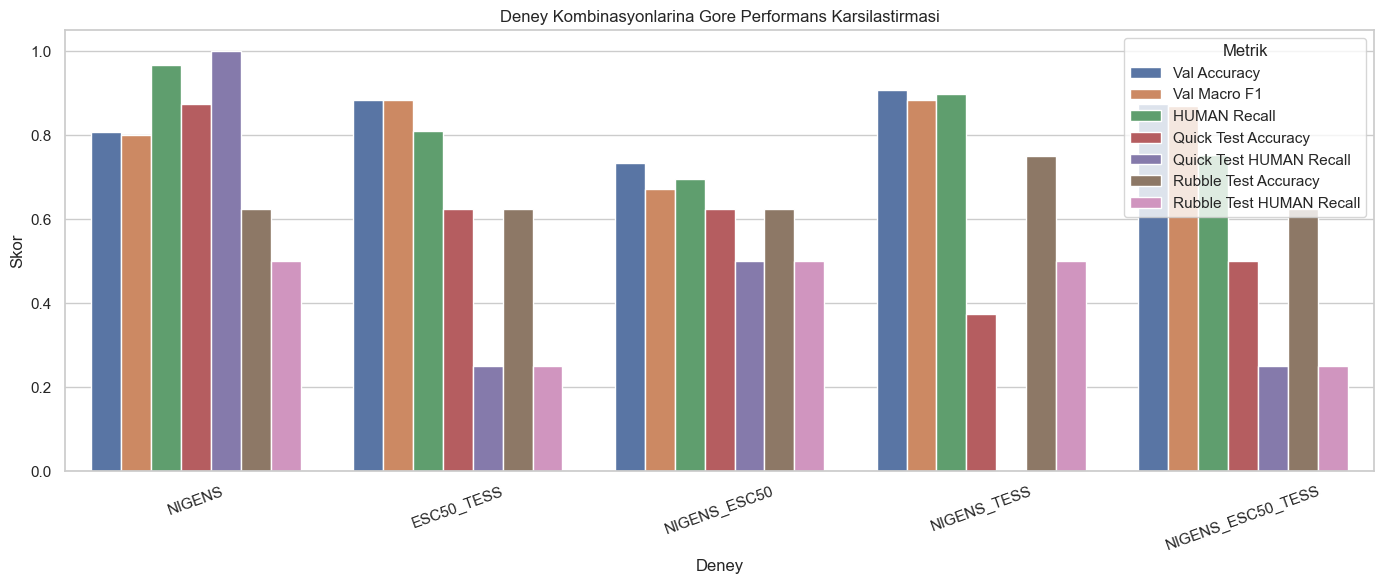

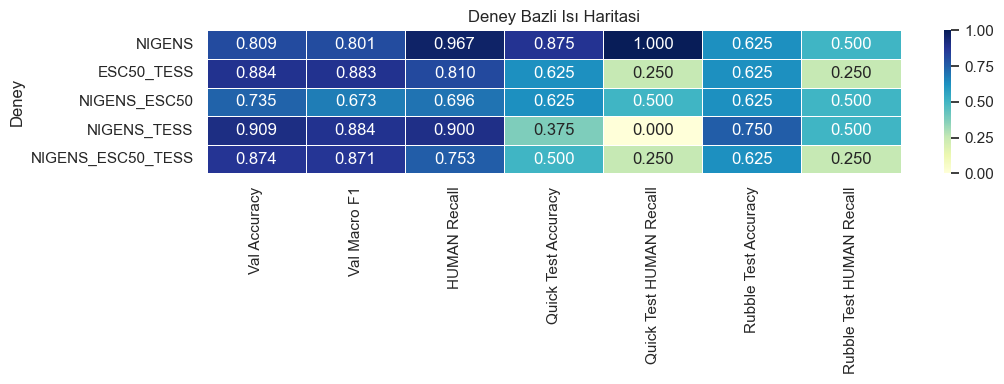

En iyi kombinasyon (Val Macro F1'e gore):


,Deney,Kullanilan Veri Setleri,Toplam Ornek,Val Accuracy,Val Macro F1,HUMAN Recall,Quick Test Accuracy,Quick Test HUMAN Recall,Rubble Test Accuracy,Rubble Test HUMAN Recall,Model Yolu
3,NIGENS_TESS,NIGENS + TESS,1367,0.908759,0.883794,0.899522,0.375,0.0,0.75,0.5,C:\projs\echo_swarm2\models\comparison_nigens_...


Bar grafik kaydedildi: C:\projs\echo_swarm2\outputs\dataset_combo_comparison_bar_tr.png
Isi haritasi kaydedildi: C:\projs\echo_swarm2\outputs\dataset_combo_comparison_heatmap_tr.png


In [11]:
if RESULTS_CSV.exists():
    results_df = pd.read_csv(RESULTS_CSV)
    metric_cols = [
        "Val Accuracy",
        "Val Macro F1",
        "HUMAN Recall",
        "Quick Test Accuracy",
        "Quick Test HUMAN Recall",
        "Rubble Test Accuracy",
        "Rubble Test HUMAN Recall",
    ]

    plot_df = results_df.melt(
        id_vars=["Deney"],
        value_vars=metric_cols,
        var_name="Metrik",
        value_name="Deger",
    )

    plt.figure(figsize=(14, 6))
    sns.barplot(data=plot_df, x="Deney", y="Deger", hue="Metrik")
    plt.ylim(0, 1.05)
    plt.title("Deney Kombinasyonlarina Gore Performans Karsilastirmasi")
    plt.ylabel("Skor")
    plt.xlabel("Deney")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(RESULTS_PNG, dpi=180, bbox_inches="tight")
    plt.show()

    heatmap_df = results_df.set_index("Deney")[metric_cols].apply(pd.to_numeric, errors="coerce")
    plt.figure(figsize=(11, max(3.5, len(heatmap_df) * 0.8)))
    sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", vmin=0, vmax=1, fmt=".3f", linewidths=0.5)
    plt.title("Deney Bazli Isı Haritasi")
    plt.tight_layout()
    plt.savefig(HEATMAP_PNG, dpi=180, bbox_inches="tight")
    plt.show()

    best_row = results_df.sort_values("Val Macro F1", ascending=False).iloc[0]
    print("En iyi kombinasyon (Val Macro F1'e gore):")
    display(best_row.to_frame().T)
    print(f"Bar grafik kaydedildi: {RESULTS_PNG}")
    print(f"Isi haritasi kaydedildi: {HEATMAP_PNG}")
else:
    print("Grafik icin once deneyleri calistirmaniz gerekiyor.")


## 12. Rapor Icin Kisa Yorum

In [12]:
if RESULTS_CSV.exists():
    results_df = pd.read_csv(RESULTS_CSV).sort_values("Val Macro F1", ascending=False).reset_index(drop=True)
    top = results_df.iloc[0]
    print(
        f"Bu notebook icindeki karsilastirmaya gore en iyi veri seti kombinasyonu "
        f"'{top['Deney']}' olarak gorunmektedir. "
        f"Bu kombinasyonun Val Accuracy degeri {top['Val Accuracy']:.4f}, "
        f"Val Macro F1 degeri {top['Val Macro F1']:.4f} ve HUMAN Recall degeri {top['HUMAN Recall']:.4f} olarak hesaplanmistir."
    )
else:
    print("Kisa yorum icin once deneyleri calistirin.")


Bu notebook icindeki karsilastirmaya gore en iyi veri seti kombinasyonu 'NIGENS_TESS' olarak gorunmektedir. Bu kombinasyonun Val Accuracy degeri 0.9088, Val Macro F1 degeri 0.8838 ve HUMAN Recall degeri 0.8995 olarak hesaplanmistir.
